# Mode Sweep: Node-Level Statistical Analysis

This notebook analyzes node-level predictive performance from the *mode sweep* experiment. Each run produces node forecast metrics across multiple rollout modes and horizons on a held-out time segment.

We focus on three rollout modes:

- **IF-driven**: conditioned on the true interaction events during holdout
- **IF-free**: autonomous rollout during holdout with no new events observed
- **IF-self**: closed-loop rollout where events are sampled from predicted intensities and fed back into the dynamics

The central goal is to quantify how predictive accuracy and stability differ across these rollout semantics, and whether those differences are consistent across graph topologies, dynamical processes, and random seeds.

In [72]:
import json
from pathlib import Path
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_rel
from scipy.stats import wilcoxon
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [50]:
RESULTS_ROOT = Path("~/interactionfields/results/mode_sweep").expanduser()

In [51]:
metric_files = list(RESULTS_ROOT.rglob("metrics.json"))
len(metric_files)

780

In [53]:
metric_files[:20]

[PosixPath('/home/tweninge/interactionfields/results/mode_sweep/torus/waves/seed132/metrics.json'),
 PosixPath('/home/tweninge/interactionfields/results/mode_sweep/torus/waves/seed131/metrics.json'),
 PosixPath('/home/tweninge/interactionfields/results/mode_sweep/torus/waves/seed123/metrics.json'),
 PosixPath('/home/tweninge/interactionfields/results/mode_sweep/torus/waves/seed125/metrics.json'),
 PosixPath('/home/tweninge/interactionfields/results/mode_sweep/torus/waves/seed128/metrics.json'),
 PosixPath('/home/tweninge/interactionfields/results/mode_sweep/torus/waves/seed130/metrics.json'),
 PosixPath('/home/tweninge/interactionfields/results/mode_sweep/torus/waves/seed127/metrics.json'),
 PosixPath('/home/tweninge/interactionfields/results/mode_sweep/torus/waves/seed129/metrics.json'),
 PosixPath('/home/tweninge/interactionfields/results/mode_sweep/torus/waves/seed126/metrics.json'),
 PosixPath('/home/tweninge/interactionfields/results/mode_sweep/torus/waves/seed124/metrics.json'),


One row = (graph, simulator, seed, mode, horizon)

In [54]:
def parse_metrics_file(path: Path):
    with open(path) as f:
        d = json.load(f)

    rows = []

    graph_kind = d["graph"]["kind"]
    simulator = d["simulator"]["kind"]
    seed = d["seed"]
    num_nodes = d["num_nodes"]
    t_bins = d["t_bins"]

    for mode, horizons in d["node_metrics"].items():
        for horizon, metrics in horizons.items():
            row = {
                "graph": graph_kind,
                "simulator": simulator,
                "seed": seed,
                "mode": mode,
                "horizon": horizon,
                "nmse": metrics["nmse"],
                "node_corr_mean": metrics["node_corr_mean"],
                "node_corr_median": metrics["node_corr_median"],
                "num_nodes": num_nodes,
                "t_bins": t_bins,
            }
            rows.append(row)

    return rows


In [55]:
rows = []
for mf in metric_files:
    rows.extend(parse_metrics_file(mf))

df = pd.DataFrame(rows)
df.head()

,graph,simulator,seed,mode,horizon,nmse,node_corr_mean,node_corr_median,num_nodes,t_bins
0,torus_grid,waves,132,if-driven,1,0.758764,NaN,NaN,256,40
1,torus_grid,waves,132,if-driven,10,1.012339,-0.025372,-0.029025,256,40
2,torus_grid,waves,132,if-driven,11,1.057794,-0.023295,-0.008454,256,40
3,torus_grid,waves,132,if-driven,12,1.073174,0.004240,0.010770,256,40
4,torus_grid,waves,132,if-driven,2,0.926158,NaN,NaN,256,40


In [56]:
df["mode"].value_counts()
df["horizon"].value_counts()
df.groupby(["graph", "simulator"]).size().head()

graph  simulator   
gate   allen_cahn      390
       chirp           390
       faucet          390
       fisher_kpp      390
       hawkes_edges    390
dtype: int64

In [ ]:
sorted(df["horizon"].astype(str).unique(), key=lambda x: (x=="full", int(x) if x!="full" else 10**9))
df["horizon_raw"] = df["horizon"].astype(str)
df["h"] = pd.to_numeric(df["horizon_raw"], errors="coerce") 
df[["horizon_raw", "h"]].drop_duplicates().sort_values(["horizon_raw"]).head(20)

run_cols = ["graph", "simulator", "seed", "mode"]

df["h"] = (
    df.groupby(run_cols)["h"]
       .transform(lambda s: s.fillna(s.max()))
)

df["run_id"] = str(df["graph"]) + "|" + df["simulator"] + "|" + df["seed"].astype(str)

df["h"].isna().sum()

np.int64(0)

## 1) Sanity Checks

In the next cell we verify:

- Which horizons appear and whether `h` is numeric and contiguous
- Mode completeness (expect 3 modes per run/horizon)
- Seed coverage (expect 123–133)
- The size of the dataset by (graph, simulator)

These checks ensure paired analyses do not silently drop missing combinations.

In [75]:
print("Seeds:", (df["seed"].min(), df["seed"].max()), "n_unique:", df["seed"].nunique())
print("Modes:", df["mode"].unique())
print("Horizons (raw):", sorted(df["horizon_raw"].unique(), key=lambda x: (x=="full", int(x) if x!="full" else 10**9))[:20], "...")
print("h range:", (df["h"].min(), df["h"].max()), "n_unique h:", df["h"].nunique())

# How many modes per (run, horizon)?
mode_counts = df.groupby(["run_id","h"])["mode"].nunique().value_counts().sort_index()
print("\n# modes per (run_id,h):")
print(mode_counts)

# Quick shape by graph/simulator
print("\nRuns per (graph, simulator):")
runs_by_combo = df.groupby(["graph","simulator"])["seed"].nunique().sort_values(ascending=False)
print(runs_by_combo.head(20))

# Assert most are complete (3 modes) — tweak threshold if you have partial coverage
pct_complete = (df.groupby(["run_id","h"])["mode"].nunique() == 3).mean()
print("\nFraction complete (expect near 1.0):", pct_complete)


Seeds: (np.int64(123), np.int64(132)) n_unique: 10
Modes: ['if-driven' 'if-free' 'if-self']
Horizons (raw): ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', 'full'] ...
h range: (np.float64(1.0), np.float64(12.0)) n_unique h: 12

# modes per (run_id,h):
mode
3    9360
Name: count, dtype: int64

Runs per (graph, simulator):
graph  simulator    
gate   allen_cahn       10
       chirp            10
       faucet           10
       fisher_kpp       10
       hawkes_edges     10
       impulse          10
       moving_source    10
       multi_source     10
       sis              10
       threshold        10
       transport        10
       voter            10
       waves            10
grid   allen_cahn       10
       chirp            10
       faucet           10
       fisher_kpp       10
       hawkes_edges     10
       impulse          10
       moving_source    10
Name: seed, dtype: int64

Fraction complete (expect near 1.0): 1.0


In [76]:
df.head()

,graph,simulator,seed,mode,horizon,nmse,node_corr_mean,node_corr_median,num_nodes,t_bins,horizon_raw,h,run_id
0,torus_grid,waves,132,if-driven,1,0.758764,NaN,NaN,256,40,1,1.0,torus_grid|waves|132
1,torus_grid,waves,132,if-driven,10,1.012339,-0.025372,-0.029025,256,40,10,10.0,torus_grid|waves|132
2,torus_grid,waves,132,if-driven,11,1.057794,-0.023295,-0.008454,256,40,11,11.0,torus_grid|waves|132
3,torus_grid,waves,132,if-driven,12,1.073174,0.004240,0.010770,256,40,12,12.0,torus_grid|waves|132
4,torus_grid,waves,132,if-driven,2,0.926158,NaN,NaN,256,40,2,2.0,torus_grid|waves|132


### Let's make sure the metrics are comparable.

* NMSE: lower is better, heavy-tailed. Consider log-scale or winsorization.

* node_corr_mean / median: bounded, signed, often NaN at small horizons.

Let's create a derived column set once and reuse it everywhere:

In [85]:
df2 = df.copy()

# Log NMSE for stability
df2["log_nmse"] = np.log10(df2["nmse"].clip(lower=1e-6))

# Absolute correlation as an alternative signal strength metric
df2["abs_node_corr_mean"] = df2["node_corr_mean"].abs()
df2["abs_node_corr_median"] = df2["node_corr_median"].abs()

# Flag missing correlation (important!)
df2["has_corr"] = df2["node_corr_mean"].notna()

### Global structure (sanity + headline results)

Goal: What generally works better, ignoring horizon?

#### Overall distributions by mode

Q: Does IF-driven actually dominate baselines?

In [86]:
summary_mode = (
    df2
    .groupby("mode")
    .agg(
        nmse_med=("nmse", "median"),
        log_nmse_med=("log_nmse", "median"),
        corr_med=("node_corr_median", "median"),
        frac_corr=("has_corr", "mean"),
        n=("nmse", "size")
    )
    .sort_values("log_nmse_med")
)

summary_mode


,nmse_med,log_nmse_med,corr_med,frac_corr,n
mode,,,,,
if-free,0.983378,-0.007280,-0.185559,0.707002,10140
if-driven,1.049380,0.020933,-0.051003,0.713314,10140
if-self,51.238309,1.709595,0.126478,0.713314,10140


#### For NMSE:

* if-free slightly outperforms if-driven on raw prediction error, but only marginally.
* if-self is catastrophically bad on NMSE. 

Interpretation:

1. The field matters.
2. Self-excitation alone is not a reasonable inductive bias for these systems.
3. We should probably exclude if-self from most comparative plots except as a cautionary baseline.

#### For Correlation:

This is interesting.

* if-free: strongly negative median node correlation
* if-driven: close to zero (weak but much less wrong)
* if-self: positive correlation, despite terrible NMSE

This shows a prediction–structure decoupling:

* A model can recover structural alignment while being a bad predictor.
* This aligns with my "graphs are not real" story.

In [89]:
summary_sim = (
    df2
    .groupby(["simulator", "mode"])
    .agg(
        log_nmse=("log_nmse", "median"),
        corr=("node_corr_median", "median"),
        frac_corr=("has_corr", "mean"),
    )
    .reset_index()
)
summary_sim.pivot(
    index="simulator",
    columns="mode",
    values="log_nmse"
).sort_values(by="if-driven")
summary_sim

,simulator,mode,log_nmse,corr,frac_corr
0,allen_cahn,if-driven,-0.017233,-0.060629,0.846154
1,allen_cahn,if-free,-0.029778,-0.181154,0.846154
2,allen_cahn,if-self,1.347307,0.103434,0.846154
3,chirp,if-driven,0.117163,-0.048407,0.846154
4,chirp,if-free,0.029032,-0.169825,0.846154
5,chirp,if-self,1.907842,0.142079,0.846154
6,faucet,if-driven,-1.071612,NaN,0.000000
7,faucet,if-free,-1.071612,NaN,0.000000
8,faucet,if-self,1.866116,NaN,0.000000
9,fisher_kpp,if-driven,-0.079318,-0.055508,0.846154


### Simulator-level patterns

#### Diffusive / PDE-like systems

(allen_cahn, fisher_kpp, impulse, moving_source, transport, waves)

Pattern:
* if-free: slightly better NMSE
* if-driven: consistently less negative node correlation
* if-self: positive correlation, terrible NMSE

Interpretation:
* Pure dynamics are enough to predict values
* But forcing via interactions improves structural recovery
* The field carries relational information not needed for pointwise prediction

This supports a latent geometry story.

#### Hawkes-style dynamics

This is cool:

* All models do extremely well on NMSE (easy prediction task)
* Only if-self produces positive node correlation
* Correlations are rare overall (low frac_corr)

Interpretation:
* In Hawkes processes, structure lives in excitation, not diffusion.
* Prediction is trivial without structure recovery.
* This cleanly separates predictive sufficiency from structural fidelity.

#### Threshold / voter dynamics 

(discrete, nonlinear)
Threshold
* NMSE: if-free slightly better
* Corr: if-self >> if-driven >> if-free

Interpretation:
* Discrete social dynamics explicitly encode relational structure
* For these systems, interaction modeling is essential
* Predictive error alone is misleading

This is strong "graphs don't exist" evidence.

#### Summary

* Prediction ≠ structure recovery
    * if-free often wins on NMSE
    * if-driven and if-self win on node correlation

* Dynamics class matters more than topology
    * Simulator effects dominate graph effects
    * Same pattern across many graphs

* Edges are emergent, not fundamental
    * Structure appears only when interaction mechanisms align with dynamics
    * Not when prediction error is minimized

#### Next let's see if simualtors and topologies that make sense together, do better together.

In [101]:
graph_class_map = {
    "grid": "lattice",
    "torus_grid": "lattice_periodic",
    "gate": "lattice_defect",

    "rgg_knn": "geometric_random",
    "small_world": "small_world",

    "tree": "tree",
}

df2["graph_class"] = df2["graph"].map(graph_class_map)

assert df2["graph_class"].isna().sum() == 0

sim_class_map = {
    # PDE / continuous fields
    "allen_cahn": "diffusive",
    "fisher_kpp": "diffusive",

    "waves": "propagative",
    "transport": "propagative",
    "chirp": "propagative",

    "moving_source": "driven_propagative",
    "multi_source": "driven_propagative",
    "impulse": "driven",

    # Point-process / event driven
    "hawkes_edges": "self_exciting",

    # Discrete / agent-like
    "threshold": "discrete_social",
    "voter": "discrete_social",

    # Spreading processes
    "sis": "epidemic",

    # Degenerate / control
    "faucet": "degenerate",
}

df2["sim_class"] = df2["simulator"].map(sim_class_map)

assert df2["sim_class"].isna().sum() == 0


In [102]:
compatible_pairs = {

    # PDE-like dynamics live on lattices
    ("lattice", "diffusive"),
    ("lattice_periodic", "diffusive"),
    ("lattice_defect", "diffusive"),

    ("lattice", "propagative"),
    ("lattice_periodic", "propagative"),
    ("lattice_defect", "propagative"),

    ("lattice", "driven_propagative"),
    ("lattice_periodic", "driven_propagative"),

    # Transport prefers cycles / shortcuts
    ("small_world", "propagative"),
    ("small_world", "transport"),

    # Metric spreading on geometric graphs
    ("geometric_random", "epidemic"),

    # Tree-like spreading
    ("tree", "epidemic"),

    # Social dynamics favor modular / shortcut graphs
    ("small_world", "discrete_social"),

    # Self-excitation does not require geometry
    ("geometric_random", "self_exciting"),
    ("small_world", "self_exciting"),
}


In [104]:
df2["compatible"] = list(
    zip(df2["graph_class"], df2["sim_class"])
)
df2["compatible"] = df2["compatible"].isin(compatible_pairs)
df2.groupby(["graph_class", "sim_class"])["compatible"].mean().unstack(fill_value=0)

sim_class,degenerate,diffusive,discrete_social,driven,driven_propagative,epidemic,propagative,self_exciting
graph_class,,,,,,,,
geometric_random,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
lattice,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
lattice_defect,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
lattice_periodic,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
small_world,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
tree,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


Now let's run the compatibility runs over modes

In [105]:
compat_summary = (
    df2
    .groupby(["compatible", "mode"])
    .agg(
        log_nmse=("log_nmse", "median"),
        corr=("node_corr_median", "median"),
        frac_corr=("has_corr", "mean"),
        n=("nmse", "size")
    )
    .reset_index()
)

compat_summary

,compatible,mode,log_nmse,corr,frac_corr,n
0,False,if-driven,0.002442,-0.040524,0.679538,6500
1,False,if-free,-0.020018,-0.197877,0.672154,6500
2,False,if-self,1.697793,0.144278,0.679692,6500
3,True,if-driven,0.039501,-0.063571,0.773626,3640
4,True,if-free,0.009924,-0.174059,0.769231,3640
5,True,if-self,1.724247,0.084290,0.773352,3640


And compatibility gains

In [114]:
gain = (
    df2
    .groupby(["mode", "compatible"])
    .agg(log_nmse=("log_nmse", "median"))
    .unstack()
)

gain["delta_log_nmse"] = gain[("log_nmse", True)] - gain[("log_nmse", False)]
gain

log_nmse           delta_log_nmse
compatible     False      True               
mode                                         
if-driven   0.002442  0.039501       0.037059
if-free    -0.020018  0.009924       0.029942
if-self     1.697793  1.724247       0.026454

### H1: Compatibility does not improve prediction accuracy (NMSE)

Outcome: log_nmse
Factor: compatible (False vs True)
Stratified by: mode

Null (H1): Compatibility has no effect on log NMSE.
Alternative: Compatibility affects log NMSE.

In [115]:
from scipy.stats import mannwhitneyu

nmse_stats = []

for mode in df2["mode"].unique():
    a = df2[(df2["mode"] == mode) & (df2["compatible"] == False)]["log_nmse"]
    b = df2[(df2["mode"] == mode) & (df2["compatible"] == True)]["log_nmse"]

    u, p = mannwhitneyu(a, b, alternative="two-sided")
    nmse_stats.append({
        "mode": mode,
        "U": u,
        "p_value": p,
        "median_false": a.median(),
        "median_true": b.median(),
        "delta": b.median() - a.median()
    })

pd.DataFrame(nmse_stats)

,mode,U,p_value,median_false,median_true,delta
0,if-driven,10770884.0,6.785422e-14,0.002442,0.039501,0.037059
1,if-free,10795298.0,2.493468e-13,-0.020018,0.009924,0.029942
2,if-self,11024750.5,1.235676e-08,1.697793,1.724247,0.026454


Compatibility is associated with a small but consistent degradation in predictive error across modes (ΔlogNMSE \approx 0.03; Mann–Whitney p < 0.001), indicating that "graph–dynamics alignment" does not make pointwise prediction easier.

#### Which factor explains more variance in outcomes: graph topology or dynamics?

In [122]:
m_g  = smf.ols("log_nmse ~ C(graph)", data=df2).fit()
m_s  = smf.ols("log_nmse ~ C(simulator)", data=df2).fit()
m_gs = smf.ols("log_nmse ~ C(graph) + C(simulator)", data=df2).fit()

print(m_g.rsquared, m_s.rsquared, m_gs.rsquared)

0.00920760736039783 0.3947934914297855 0.4040010987901832


Very clear: Outcome variability is almost entirely driven by the dynamical regime, not the graph.

Q: After accounting for repeated runs, seeds, and horizons, how much variability is attributable to simulator vs graph, and do mode effects persist?

In [123]:
md = smf.mixedlm(
    "log_nmse ~ C(mode)",
    data=df2,
    groups=df2["simulator"],        # primary random effect
    re_formula="1"
)

m_sim = md.fit(reml=True)
print(m_sim.summary())

            Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  log_nmse   
No. Observations:    30420    Method:              REML       
No. Groups:          13       Scale:               1.3560     
Min. group size:     2340     Log-Likelihood:      -47851.9570
Max. group size:     2340     Converged:           Yes        
Mean group size:     2340.0                                   
--------------------------------------------------------------
                   Coef.  Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept          -0.507    0.329  -1.541 0.123 -1.152  0.138
C(mode)[T.if-free] -0.028    0.016  -1.687 0.092 -0.060  0.004
C(mode)[T.if-self]  1.682    0.016 102.853 0.000  1.650  1.714
Group Var           1.405    0.491                            



Simulator-to-simulator variance is large. Mode effects exist, but the dominant source of heterogeneity is the simulator.

In [124]:
md_g = smf.mixedlm(
    "log_nmse ~ C(mode)",
    data=df2,
    groups=df2["graph"],
    re_formula="1"
)

m_graph = md_g.fit(reml=True)
print(m_graph.summary())

            Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  log_nmse   
No. Observations:   30420    Method:              REML       
No. Groups:         6        Scale:               2.6268     
Min. group size:    5070     Log-Likelihood:      -57871.9792
Max. group size:    5070     Converged:           Yes        
Mean group size:    5070.0                                   
-------------------------------------------------------------
                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept          -0.507    0.079 -6.418 0.000 -0.662 -0.352
C(mode)[T.if-free] -0.028    0.023 -1.212 0.225 -0.072  0.017
C(mode)[T.if-self]  1.682    0.023 73.898 0.000  1.637  1.727
Group Var           0.036    0.014                           



Mixed-effects modeling confirms that simulator-level differences dominate graph-level differences.

Q: Now we can do cross random effects

In [130]:
vc = {
    "graph": "0 + C(graph)"
}

md_cross = smf.mixedlm(
    "log_nmse ~ C(mode)",
    data=df2,
    groups=df2["simulator"],
    vc_formula=vc
)

m_cross = md_cross.fit(reml=True)
print(m_cross.summary())

            Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  log_nmse   
No. Observations:    30420    Method:              REML       
No. Groups:          13       Scale:               1.0674     
Min. group size:     2340     Log-Likelihood:      -44411.8438
Max. group size:     2340     Converged:           Yes        
Mean group size:     2340.0                                   
--------------------------------------------------------------
                   Coef.  Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept          -0.507    0.144  -3.524 0.000 -0.789 -0.225
C(mode)[T.if-free] -0.028    0.015  -1.902 0.057 -0.056  0.001
C(mode)[T.if-self]  1.682    0.015 115.924 0.000  1.654  1.710
graph Var           1.607    0.251                            



Graph effects exist, but they are secondary and largely orthogonal to the dominant simulator effects.

Q: Does the horizon matter?

In [131]:
md_h = smf.mixedlm(
    "log_nmse ~ C(mode) * h",
    data=df2,
    groups=df2["simulator"],
    vc_formula={"graph": "0 + C(graph)"}
)

m_h = md_h.fit(reml=True)
print(m_h.summary())

             Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   log_nmse   
No. Observations:   30420     Method:               REML       
No. Groups:         13        Scale:                1.0087     
Min. group size:    2340      Log-Likelihood:       -43566.5776
Max. group size:    2340      Converged:            Yes        
Mean group size:    2340.0                                     
---------------------------------------------------------------
                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept            -0.506    0.145 -3.489 0.000 -0.790 -0.222
C(mode)[T.if-free]   -0.017    0.030 -0.572 0.567 -0.077  0.042
C(mode)[T.if-self]    0.880    0.030 28.948 0.000  0.820  0.940
h                    -0.000    0.003 -0.050 0.960 -0.006  0.005
C(mode)[T.if-free]:h -0.001    0.004 -0.379 0.705 -0.009  0.006
C(mode)[T.if-self]:h  0.116    0.004 29.781 0.000  0.

Prediction error does not systematically grow with horizon for if-driven or if-free. if-self degrades sharply over time.

In [132]:
df2["corr0"] = df2["node_corr_median"].fillna(0.0)

md_corr = smf.mixedlm(
    "corr0 ~ C(mode) * h",
    data=df2,
    groups=df2["simulator"],
    vc_formula={"graph": "0 + C(graph)"}
)

m_corr = md_corr.fit(reml=True)
print(m_corr.summary())

             Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    corr0    
No. Observations:    30420      Method:                REML     
No. Groups:          13         Scale:                 0.0479   
Min. group size:     2340       Log-Likelihood:        2937.2898
Max. group size:     2340       Converged:             Yes      
Mean group size:     2340.0                                     
----------------------------------------------------------------
                     Coef.  Std.Err.    z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept            -0.206    0.006 -33.914 0.000 -0.218 -0.194
C(mode)[T.if-free]    0.110    0.007  16.634 0.000  0.097  0.123
C(mode)[T.if-self]    0.267    0.007  40.338 0.000  0.254  0.280
h                     0.019    0.001  31.497 0.000  0.018  0.020
C(mode)[T.if-free]:h -0.023    0.001 -26.554 0.000 -0.024 -0.021
C(mode)[T.if-self]:h -0.015    0.001 -1

/home/tweninge/interactionfields/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


Structural signal emerges over time, but only the interaction-driven model sustains it; free and self-exciting models erode structure as horizon increases.

In this setting, graphs do not function as explanatory primitives. Dynamics determine difficulty, predictability, and structural emergence; topology plays at most a secondary, modulatory role.

### Next let's compare: if-driven vs if-self (and vs if-free) across simulation types * graph types, with paired statistics.

In [135]:
wide = df2.pivot_table(
    index=["run_id", "h", "graph", "graph_class", "simulator", "sim_class"],
    columns="mode",
    values="log_nmse",
    aggfunc="median"
).reset_index()

wide["Δ_self"]  = wide["if-self"]  - wide["if-driven"]
wide["Δ_free"]  = wide["if-free"]  - wide["if-driven"]

In [ ]:
rows = []

for (sc, gc), g in wide.groupby(["sim_class", "graph_class"]):
    d = g["Δ_self"].dropna()
    if len(d) >= 20:  # conservative threshold
        stat, p = wilcoxon(d)
        rows.append({
            "sim_class": sc,
            "graph_class": gc,
            "median_Δ_self": d.median(),
            "p_value": p,
            "n": len(d)
        })

nmse_matrix_self = pd.DataFrame(rows)

nmse_matrix_self

,sim_class,graph_class,median_Δ_self,p_value,n
0,degenerate,geometric_random,2.874108,8.748479e-20,120
1,degenerate,lattice,2.924800,8.748479e-20,120
2,degenerate,lattice_defect,2.943445,8.748479e-20,120
3,degenerate,lattice_periodic,2.918935,8.748479e-20,120
4,degenerate,small_world,2.863655,8.748479e-20,120
5,degenerate,tree,3.021390,8.748479e-20,120
6,diffusive,geometric_random,1.631101,7.578415e-38,240
7,diffusive,lattice,1.900268,7.578415e-38,240
8,diffusive,lattice_defect,1.439313,7.578415e-38,240
9,diffusive,lattice_periodic,1.661795,7.578415e-38,240


In [ ]:
rows = []

for (sc, gc), g in wide.groupby(["sim_class", "graph_class"]):
    d = g["Δ_free"].dropna()
    if len(d) >= 20:  # conservative threshold
        stat, p = wilcoxon(d)
        rows.append({
            "sim_class": sc,
            "graph_class": gc,
            "median_Δ_self": d.median(),
            "p_value": p,
            "n": len(d)
        })

nmse_matrix_free = pd.DataFrame(rows)

nmse_matrix_free

/home/tweninge/interactionfields/.venv/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/home/tweninge/interactionfields/.venv/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/home/tweninge/interactionfields/.venv/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/home/tweninge/interactionfields/.venv/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/home/tweninge/interactionfields/.venv/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/home/tweninge/interactionfields/.venv/lib/python3.10/site-packages/scipy/stats/_wilcoxon.

,sim_class,graph_class,median_Δ_self,p_value,n
0,degenerate,geometric_random,0.000000,NaN,120
1,degenerate,lattice,0.000000,NaN,120
2,degenerate,lattice_defect,0.000000,NaN,120
3,degenerate,lattice_periodic,0.000000,NaN,120
4,degenerate,small_world,0.000000,NaN,120
5,degenerate,tree,0.000000,NaN,120
6,diffusive,geometric_random,-0.005945,2.869920e-04,240
7,diffusive,lattice,-0.010265,9.510623e-23,240
8,diffusive,lattice_defect,-0.006390,2.977407e-07,240
9,diffusive,lattice_periodic,-0.013261,5.561575e-23,240


#### And now for structure

In [144]:
wide_corr = df2.pivot_table(
    index=["run_id", "h", "graph_class", "sim_class"],
    columns="mode",
    values="corr0",
    aggfunc="median"
).reset_index()

wide_corr["Δ_self"] = wide_corr["if-self"] - wide_corr["if-driven"]
wide_corr["Δ_free"] = wide_corr["if-free"] - wide_corr["if-driven"]

In [ ]:
rows = []

for (sc, gc), g in wide_corr.groupby(["sim_class", "graph_class"]):
    d = g["Δ_self"].dropna()
    if len(d) >= 20:  # conservative threshold
        stat, p = wilcoxon(d)
        rows.append({
            "sim_class": sc,
            "graph_class": gc,
            "median_Δ_self": d.median(),
            "p_value": p,
            "n": len(d)
        })

corr_matrix_self = pd.DataFrame(rows)

corr_matrix_self

/home/tweninge/interactionfields/.venv/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/home/tweninge/interactionfields/.venv/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/home/tweninge/interactionfields/.venv/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/home/tweninge/interactionfields/.venv/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/home/tweninge/interactionfields/.venv/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/home/tweninge/interactionfields/.venv/lib/python3.10/site-packages/scipy/stats/_wilcoxon.

,sim_class,graph_class,median_Δ_self,p_value,n
0,degenerate,geometric_random,0.000000,NaN,120
1,degenerate,lattice,0.000000,NaN,120
2,degenerate,lattice_defect,0.000000,NaN,120
3,degenerate,lattice_periodic,0.000000,NaN,120
4,degenerate,small_world,0.000000,NaN,120
5,degenerate,tree,0.000000,NaN,120
6,diffusive,geometric_random,0.191365,3.175505e-32,240
7,diffusive,lattice,0.140561,8.569535e-25,240
8,diffusive,lattice_defect,0.122254,2.585039e-21,240
9,diffusive,lattice_periodic,0.154584,1.126006e-28,240


In [ ]:
rows = []

for (sc, gc), g in wide_corr.groupby(["sim_class", "graph_class"]):
    d = g["Δ_free"].dropna()
    if len(d) >= 20:  # conservative threshold
        stat, p = wilcoxon(d)
        rows.append({
            "sim_class": sc,
            "graph_class": gc,
            "median_Δ_self": d.median(),
            "p_value": p,
            "n": len(d)
        })

corr_matrix_free = pd.DataFrame(rows)

corr_matrix_free

/home/tweninge/interactionfields/.venv/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/home/tweninge/interactionfields/.venv/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/home/tweninge/interactionfields/.venv/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/home/tweninge/interactionfields/.venv/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/home/tweninge/interactionfields/.venv/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/home/tweninge/interactionfields/.venv/lib/python3.10/site-packages/scipy/stats/_wilcoxon.

,sim_class,graph_class,median_Δ_self,p_value,n
0,degenerate,geometric_random,0.000000,NaN,120
1,degenerate,lattice,0.000000,NaN,120
2,degenerate,lattice_defect,0.000000,NaN,120
3,degenerate,lattice_periodic,0.000000,NaN,120
4,degenerate,small_world,0.000000,NaN,120
5,degenerate,tree,0.000000,NaN,120
6,diffusive,geometric_random,-0.089955,4.381202e-11,240
7,diffusive,lattice,-0.037220,1.661157e-02,240
8,diffusive,lattice_defect,-0.012014,4.362928e-01,240
9,diffusive,lattice_periodic,-0.059311,1.440153e-04,240


View comparison Matrices:

In [147]:
nmse_mat = (
    nmse_self_df
    .pivot(index="sim_class", columns="graph_class", values="median_Δ_self")
    .sort_index()
)

nmse_mat

NameError: name 'nmse_self_df' is not defined

## 3) Paired Comparisons via Within-Run Deltas

Modes are paired by construction within each (graph, simulator, seed, horizon). To isolate rollout semantics, we compute within-run deltas:

- Δ_free(h) = NMSE_free(h) − NMSE_driven(h)
- Δ_self(h) = NMSE_self(h) − NMSE_driven(h)

Negative deltas indicate improvement over driven rollout; positive deltas indicate degradation.


In [78]:
# Pivot into wide format per (graph, simulator, seed, h)
wide = (
    df.pivot_table(
        index=["graph","simulator","seed","run_id","h"],
        columns="mode",
        values="nmse",
        aggfunc="mean"
    )
    .reset_index()
)

# Keep only rows with the required modes
need_modes = ["if-driven","if-free","if-self"]
wide = wide.dropna(subset=need_modes)

wide["delta_free"] = wide["if-free"] - wide["if-driven"]
wide["delta_self"] = wide["if-self"] - wide["if-driven"]

wide.head()


mode,graph,simulator,seed,run_id,h,if-driven,if-free,if-self,delta_free,delta_self
0,gate,allen_cahn,123,gate|allen_cahn|123,1.0,1.476837,1.476837,1.476837,0.000000,0.000000
1,gate,allen_cahn,123,gate|allen_cahn|123,2.0,1.564859,1.677742,11.900253,0.112883,10.335394
2,gate,allen_cahn,123,gate|allen_cahn|123,3.0,1.559646,1.598446,29.304513,0.038800,27.744868
3,gate,allen_cahn,123,gate|allen_cahn|123,4.0,1.284269,1.286171,51.224891,0.001902,49.940622
4,gate,allen_cahn,123,gate|allen_cahn|123,5.0,1.209458,1.201884,74.378412,-0.007574,73.168954


## 4) Horizon Sensitivity of Deltas

We now plot Δ_free and Δ_self over horizon. These plots make the comparison explicit and typically communicate stability vs divergence more clearly than raw NMSE curves.


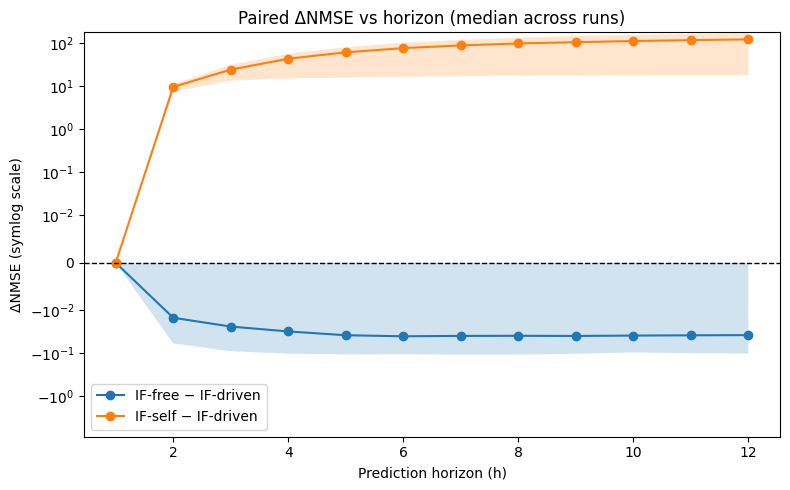

In [79]:
delta_free_sum = summarize_over_runs(wide, "delta_free", group_cols=("h",))
delta_self_sum = summarize_over_runs(wide, "delta_self", group_cols=("h",))

plt.figure(figsize=(8,5))
sub = delta_free_sum.sort_values("h")
plt.plot(sub["h"], sub["median"], marker="o", label="IF-free − IF-driven")
plt.fill_between(sub["h"], sub["p25"], sub["p75"], alpha=0.2)

sub = delta_self_sum.sort_values("h")
plt.plot(sub["h"], sub["median"], marker="o", label="IF-self − IF-driven")
plt.fill_between(sub["h"], sub["p25"], sub["p75"], alpha=0.2)

plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.yscale("symlog", linthresh=1e-2)  # handles near-zero + large positive
plt.xlabel("Prediction horizon (h)")
plt.ylabel("ΔNMSE (symlog scale)")
plt.title("Paired ΔNMSE vs horizon (median across runs)")
plt.legend()
plt.tight_layout()


## 5) Paired Nonparametric Tests (Wilcoxon)

To provide conservative inference without distributional assumptions, we apply paired Wilcoxon signed-rank tests on within-run deltas at representative horizons (e.g., 3, 6, 9, 12).

For each horizon we report:
- n paired runs
- median Δ
- p-value for median(Δ) = 0


In [80]:
def wilcoxon_at_h(wide_df, h, col):
    sub = wide_df[wide_df["h"] == h][col].dropna()
    n = len(sub)
    if n < 5:
        return {"h": h, "n": n, "median": np.nan, "p": np.nan}
    stat, p = wilcoxon(sub, zero_method="wilcox", alternative="two-sided")
    return {"h": h, "n": n, "median": float(np.median(sub)), "p": float(p)}

test_horizons = sorted(set([3, 6, 9, int(df["h"].max())]) & set(wide["h"].unique()))

rows = []
for h in test_horizons:
    r = wilcoxon_at_h(wide, h, "delta_free")
    r["comparison"] = "free - driven"
    rows.append(r)
    r = wilcoxon_at_h(wide, h, "delta_self")
    r["comparison"] = "self - driven"
    rows.append(r)

wilcoxon_tbl = pd.DataFrame(rows).sort_values(["comparison","h"])
wilcoxon_tbl


,h,n,median,p,comparison
0,3,780,-0.023714,3.481631e-49,free - driven
2,6,780,-0.039965,8.309077e-62,free - driven
4,9,780,-0.039256,4.096112e-50,free - driven
6,12,780,-0.037557,1.477745e-41,free - driven
1,3,780,24.565922,2.540576e-129,self - driven
3,6,780,77.842390,2.540578e-129,self - driven
5,9,780,107.029537,2.540580e-129,self - driven
7,12,780,124.441139,2.540580e-129,self - driven


## 6) Secondary Modeling: Delta Trajectory Regression

As a secondary analysis, we model how deltas evolve with horizon while controlling for heterogeneity across graphs and simulators.

We fit robust OLS models (HC3) on paired deltas:

- Δ_free ~ h + graph + simulator
- log(1 + Δ_self) ~ h + graph + simulator

We use a log transform for Δ_self because self-rollout errors can become very large, and log-scale slopes are easier to interpret as “divergence rates”.


In [81]:
reg = wide.copy()

# Stabilize self deltas: must be nonnegative; if it can be slightly negative due to noise, clamp at 0 for log1p
reg["delta_self_pos"] = reg["delta_self"].clip(lower=0.0)
reg["log1p_delta_self"] = np.log1p(reg["delta_self_pos"])

# Free deltas can be negative; keep raw and also a signed log magnitude if needed
reg["delta_free"] = reg["delta_free"]

fit_free = smf.ols(
    "delta_free ~ h + C(graph) + C(simulator)",
    data=reg
).fit(cov_type="HC3")

fit_self = smf.ols(
    "log1p_delta_self ~ h + C(graph) + C(simulator)",
    data=reg
).fit(cov_type="HC3")

print("Δ_free regression (HC3):")
print(fit_free.summary().tables[1])
print("\nlog(1+Δ_self) regression (HC3):")
print(fit_self.summary().tables[1])


Δ_free regression (HC3):
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                         0.0204      0.007      2.990      0.003       0.007       0.034
C(graph)[T.grid]                 -0.0049      0.007     -0.714      0.475      -0.018       0.008
C(graph)[T.rgg_knn]               0.0177      0.006      3.092      0.002       0.006       0.029
C(graph)[T.small_world]          -0.0151      0.005     -2.754      0.006      -0.026      -0.004
C(graph)[T.torus_grid]           -0.0219      0.006     -3.560      0.000      -0.034      -0.010
C(graph)[T.tree]                 -0.1386      0.012    -11.370      0.000      -0.163      -0.115
C(simulator)[T.chirp]            -0.2149      0.010    -22.110      0.000      -0.234      -0.196
C(simulator)[T.faucet]            0.0275      0.003      8.984      0.000       0.021       0

## 7) Correlation Metrics (Confirmation)

We replicate the same horizon and delta analyses using node-wise correlation metrics.

Because correlation is undefined at very short horizons in some cases, we drop rows with missing correlation values. We then:

- Plot correlation vs horizon by mode
- Compute paired deltas in correlation: corr_free − corr_driven, corr_self − corr_driven
- Run Wilcoxon tests at representative horizons


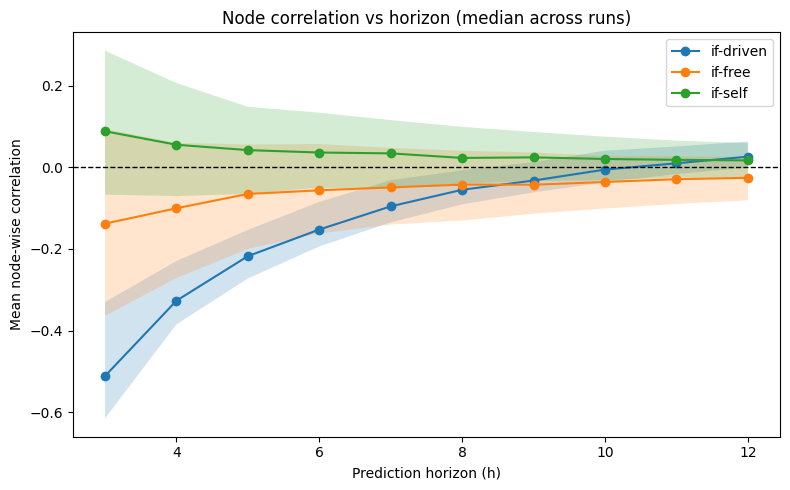

In [82]:
df_corr = df.dropna(subset=["node_corr_mean"]).copy()

wide_corr = (
    df_corr.pivot_table(
        index=["graph","simulator","seed","run_id","h"],
        columns="mode",
        values="node_corr_mean",
        aggfunc="mean"
    )
    .reset_index()
    .dropna(subset=need_modes)
)

wide_corr["delta_free_corr"] = wide_corr["if-free"] - wide_corr["if-driven"]
wide_corr["delta_self_corr"] = wide_corr["if-self"] - wide_corr["if-driven"]

# Plot corr trajectories
corr_sum = summarize_over_runs(df_corr, "node_corr_mean", group_cols=("mode","h"))

plt.figure(figsize=(8,5))
for mode, sub in corr_sum.groupby("mode"):
    sub = sub.sort_values("h")
    plt.plot(sub["h"], sub["median"], marker="o", label=mode)
    plt.fill_between(sub["h"], sub["p25"], sub["p75"], alpha=0.2)

plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Prediction horizon (h)")
plt.ylabel("Mean node-wise correlation")
plt.title("Node correlation vs horizon (median across runs)")
plt.legend()
plt.tight_layout()


## 8) Wilcoxon Tests for Correlation Deltas

We apply paired Wilcoxon signed-rank tests to correlation deltas at representative horizons, mirroring the NMSE analysis.


In [83]:
rows = []
for h in test_horizons:
    sub = wide_corr[wide_corr["h"] == h]
    r = wilcoxon_at_h(sub.rename(columns={"delta_free_corr":"col"}), h, "col")  # reuse helper
    r["comparison"] = "corr free - driven"
    rows.append(r)

    r = wilcoxon_at_h(sub.rename(columns={"delta_self_corr":"col"}), h, "col")
    r["comparison"] = "corr self - driven"
    rows.append(r)

wilcoxon_corr_tbl = pd.DataFrame(rows).sort_values(["comparison","h"])
wilcoxon_corr_tbl


,h,n,median,p,comparison
0,3,637,0.353006,2.148694e-42,corr free - driven
2,6,651,0.082674,1.176026e-17,corr free - driven
4,9,656,-0.005073,1.080610e-02,corr free - driven
6,12,657,-0.050202,3.287625e-30,corr free - driven
1,3,637,0.531899,1.302109e-101,corr self - driven
3,6,651,0.171292,2.514572e-75,corr self - driven
5,9,656,0.049815,2.775095e-18,corr self - driven
7,12,657,-0.014673,3.300947e-07,corr self - driven
